# ANALYSIS SOLAR 1. peanuts legacy


Each section states what is being computed or checked before running the numerical block. The notebook follows the root `run*.py` workflows, but expands them into reusable diagnostics for solar production, Earth propagation, annual averaging, and detected flavour content.


## 1. Libraries

This section imports the numerical, plotting, filesystem, and torch libraries used by the analysis.


In [1]:
from __future__ import annotations

import math
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from tpeanuts.flux_propagation.pipeline_legacypeanuts import _ensure_legacy_default_data_aliases

from tpeanuts.util.notebooks import find_repo_root, save_and_show, save_figure, show_figure
from tpeanuts.util.solar import load_spectrum_table, normalized_spectrum, relative_flux_density
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

_ensure_legacy_default_data_aliases()

from peanuts.pmns import PMNS as LegacyPMNS
from peanuts.solar import SolarModel, Psolar, solar_flux_mass
from peanuts.earth import earthdensity, Pearth
from peanuts.time_average import NadirExposure


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Warning!: Python module pyslha not found, disabling slha reading routines


## 2. Paths and Configuration

This section separates filesystem discovery from the physics and plotting parameters used below.


### 2.1. Paths

This subsection locates the repository, data folders, spectrum files, Earth-density tables, and output directory.


In [2]:
DATA_DIR = PACKAGE_DIR / "data"
LEGACY_DATA_DIR = DATA_DIR / "peanuts"
SOLAR_DATA_DIR = DATA_DIR / "solar"
SOLAR_SPECTRA_DIR = SOLAR_DATA_DIR / "spectra"
EARTH_DENSITY_TPEANUTS = DATA_DIR / "density" / "earth_density.csv"
EARTH_DENSITY_LEGACY = LEGACY_DATA_DIR / "Earth_Density.csv"

DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_ANALYSIS_SOLAR / "analysis_solar1_peanuts_legacy"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


SHOW_PLOTS = True

print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\analysis\solar\analysis_solar1_peanuts_legacy


### 2.2. Configuration Parameters

This subsection defines mixing parameters, energy grids, detector settings, annual exposure settings, and imports the legacy `peanuts` API used by the root `run*.py` scripts.


In [3]:
DEVICE = torch.device("cpu")
DTYPE = torch.float64
CDTYPE = torch.complex128

THETA12 = 0.59
THETA13 = 0.15
THETA23 = 0.78
DELTA_CP = 1.20
DM21_EV2 = 7.42e-5
DM3L_EV2 = 2.517e-3

FLAVOUR_LABELS = [r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"]
SOURCE_ORDER = ["pp", "7Be", "8B", "hep", "13N", "15O", "17F"]
ENERGY_MEV = np.linspace(0.2, 18.0, 90)
EARTH_METHOD_ENERGY_MEV = np.linspace(1.0, 18.0, 18)
EARTH_ENERGY_MEV = 10.0
EARTH_DEPTH_M = 2000.0
NADIR_ANGLES = [0.25 * math.pi, 0.50 * math.pi, 0.75 * math.pi]
SOLAR_DETECTOR_NADIR = 0.25 * math.pi
SOLAR_DETECTOR_ENERGY_MEV = 10.0
DETECTOR_LATITUDE_RAD = math.radians(42.0)
ANNUAL_NADIR_SAMPLES = 13
ANNUAL_ENERGY_MEV = np.linspace(0.5, 18.0, 24)
SECONDS_PER_YEAR = 365.25 * 24.0 * 3600.0
DETECTOR_AREA_CM2 = 1.0

plt.rcParams.update({"figure.figsize": (8, 4.8), "axes.grid": True, "grid.alpha": 0.3})


### 2.3. Helper Functions


In [4]:
def plot_probability_and_flux(energy_mev: np.ndarray, probabilities: np.ndarray, fluxes: np.ndarray, title: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True)
    for i, label in enumerate(FLAVOUR_LABELS):
        axes[0].plot(energy_mev, probabilities[:, i], label=label)
        axes[1].plot(energy_mev, fluxes[:, i], label=label)
    axes[0].set_xlabel("Energy [MeV]")
    axes[0].set_ylabel("Probability")
    axes[0].set_title("Detector probabilities")
    axes[1].set_xlabel("Energy [MeV]")
    axes[1].set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ MeV$^{-1}$]")
    axes[1].set_title("Detected flavour flux")
    axes[1].set_yscale('log')
    axes[0].legend()
    axes[1].legend()
    fig.suptitle(title, fontsize=15)
    fig.tight_layout()
    save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

legacy_pmns = LegacyPMNS(THETA12, THETA13, THETA23, DELTA_CP)
legacy_solar = SolarModel(
    solar_model_file=str(LEGACY_DATA_DIR / "nudistr_b16_agss09.dat"),
    flux_file=str(LEGACY_DATA_DIR / "fluxes_b16.dat"),
    spectrum_files={
        "8B": str(LEGACY_DATA_DIR / "8B_shape_Ortiz_et_al.csv"),
        "hep": str(LEGACY_DATA_DIR / "hep_shape.csv"),
        "pp": str(LEGACY_DATA_DIR / "pp_shape.csv"),
        "17F": str(LEGACY_DATA_DIR / "f17_shape.csv"),
        "7Beground": str(LEGACY_DATA_DIR / "be7ground_shape.csv"),
        "7Beexcited": str(LEGACY_DATA_DIR / "be7excited_shape.csv"),
        "13N": str(LEGACY_DATA_DIR / "n13_shape.csv"),
        "15O": str(LEGACY_DATA_DIR / "o15_shape.csv"),
    },
)
legacy_earth = earthdensity(density_file=str(EARTH_DENSITY_LEGACY), tabulated_density=False)
available_sources = [s for s in SOURCE_ORDER if legacy_solar.has_fraction(s)]
print("Legacy solar sources:", available_sources)


Legacy solar sources: ['pp', '7Be', '8B', 'hep', '13N', '15O', '17F']


### 2.4. Solar and Earth Density Profiles

This subsection checks the electron-density profiles used by the solar and Earth propagation calculations.


Saved figure: V:\output\analysis\solar\analysis_solar1_peanuts_legacy\figure_001.png


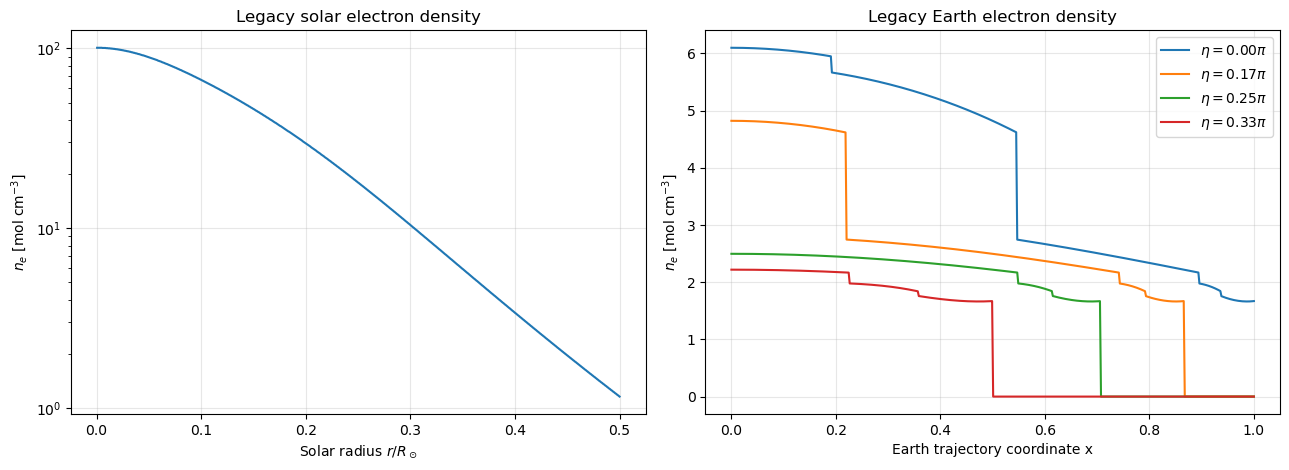

WindowsPath('V:/output/analysis/solar/analysis_solar1_peanuts_legacy/figure_001.png')

In [5]:
radius = np.asarray(legacy_solar.radius(), dtype=float)
solar_density = np.asarray(legacy_solar.density(), dtype=float)
x = np.linspace(0.0, 1.0, 500)
etas = [0.0, math.pi / 6.0, math.pi / 4.0, math.pi / 3.0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].semilogy(radius, solar_density)
axes[0].set_xlabel(r"Solar radius $r/R_\odot$")
axes[0].set_ylabel(r"$n_e$ [mol cm$^{-3}$]")
axes[0].set_title("Legacy solar electron density")

for eta in etas:
    axes[1].plot(x, [legacy_earth.call(float(xi), float(eta)) for xi in x], label=rf"$\eta={eta/math.pi:.2f}\pi$")
axes[1].set_xlabel("Earth trajectory coordinate x")
axes[1].set_ylabel(r"$n_e$ [mol cm$^{-3}$]")
axes[1].set_title("Legacy Earth electron density")
axes[1].legend()
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 3. Solar Production

This section checks where neutrinos are produced in the Sun and how each source maps into flavour probabilities before crossing Earth.


### 3.1. Production Profiles

This subsection plots the radial production profile for each solar neutrino source.


Saved figure: V:\output\analysis\solar\analysis_solar1_peanuts_legacy\figure_002.png


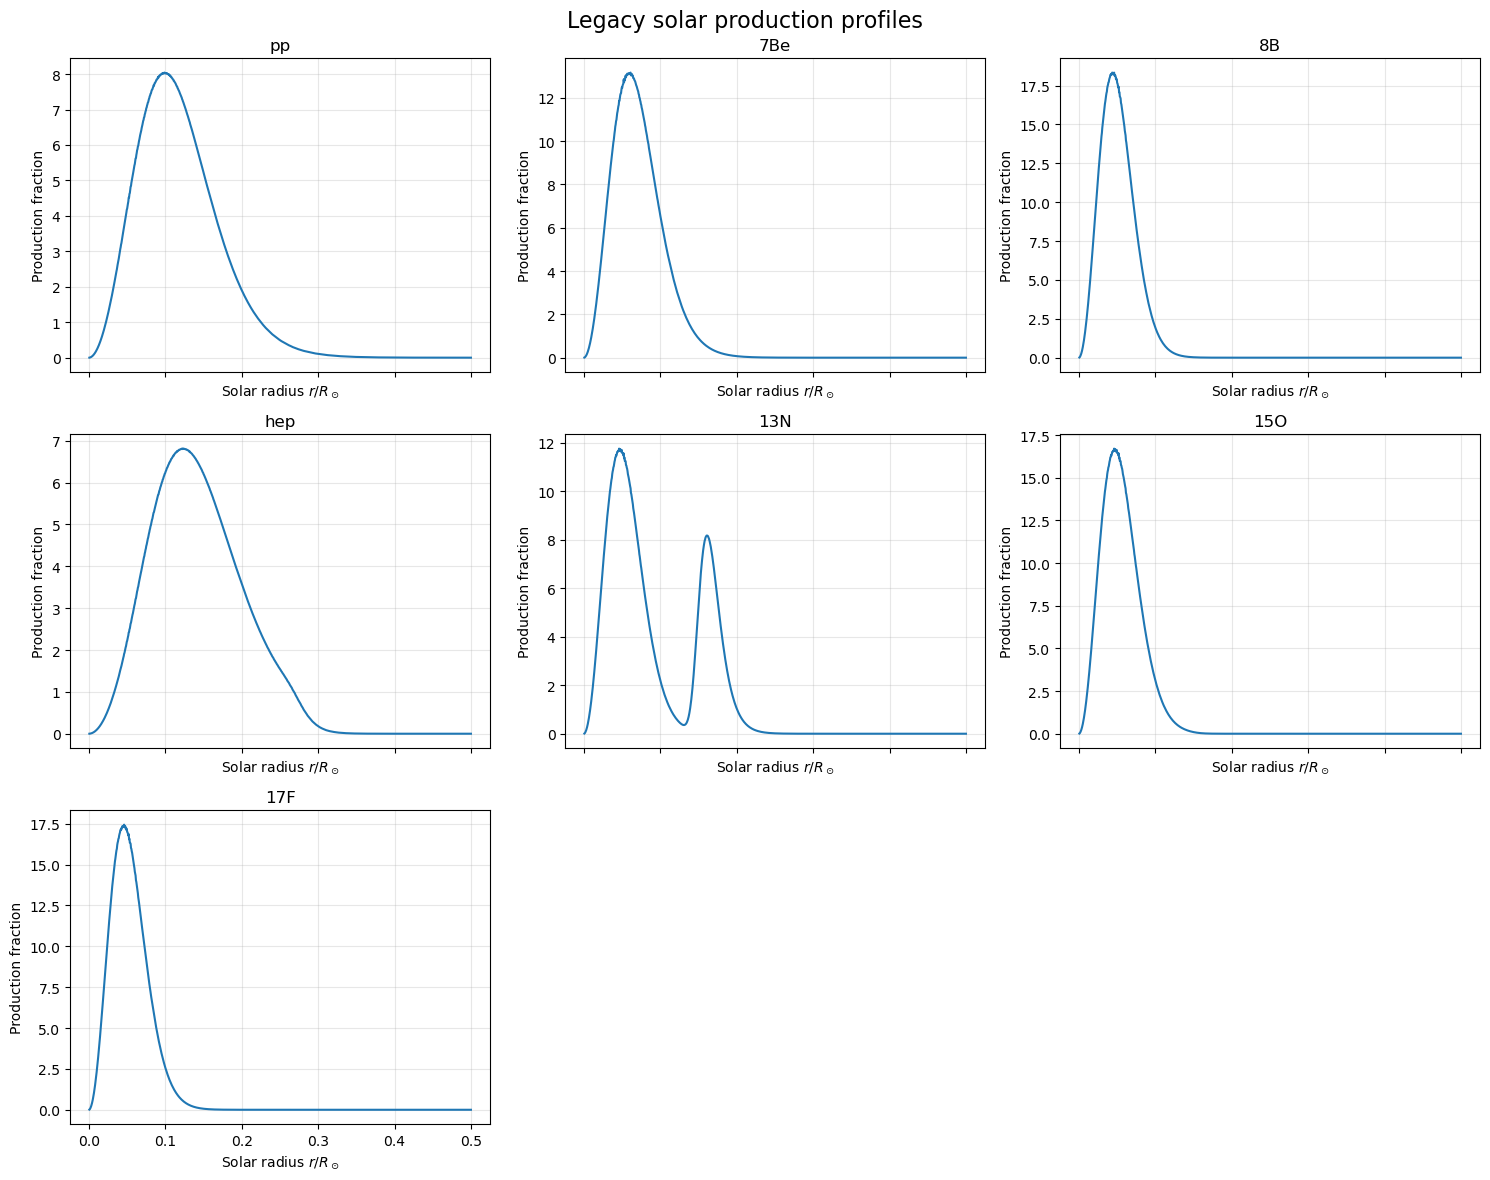

WindowsPath('V:/output/analysis/solar/analysis_solar1_peanuts_legacy/figure_002.png')

In [6]:
ncols = 3
nrows = int(np.ceil(len(available_sources) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharex=True)
axes = np.asarray(axes).reshape(-1)
for ax, source in zip(axes, available_sources):
    ax.plot(legacy_solar.radius(), legacy_solar.fraction(source))
    ax.set_title(source)
    ax.set_xlabel(r"Solar radius $r/R_\odot$")
    ax.set_ylabel("Production fraction")
for ax in axes[len(available_sources):]:
    ax.axis("off")
fig.suptitle("Legacy solar production profiles", fontsize=16)
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


### 3.2. Solar Flavour Production by Source

This subsection computes the solar flavour probabilities for every source and energy point.


Saved figure: V:\output\analysis\solar\analysis_solar1_peanuts_legacy\figure_003.png


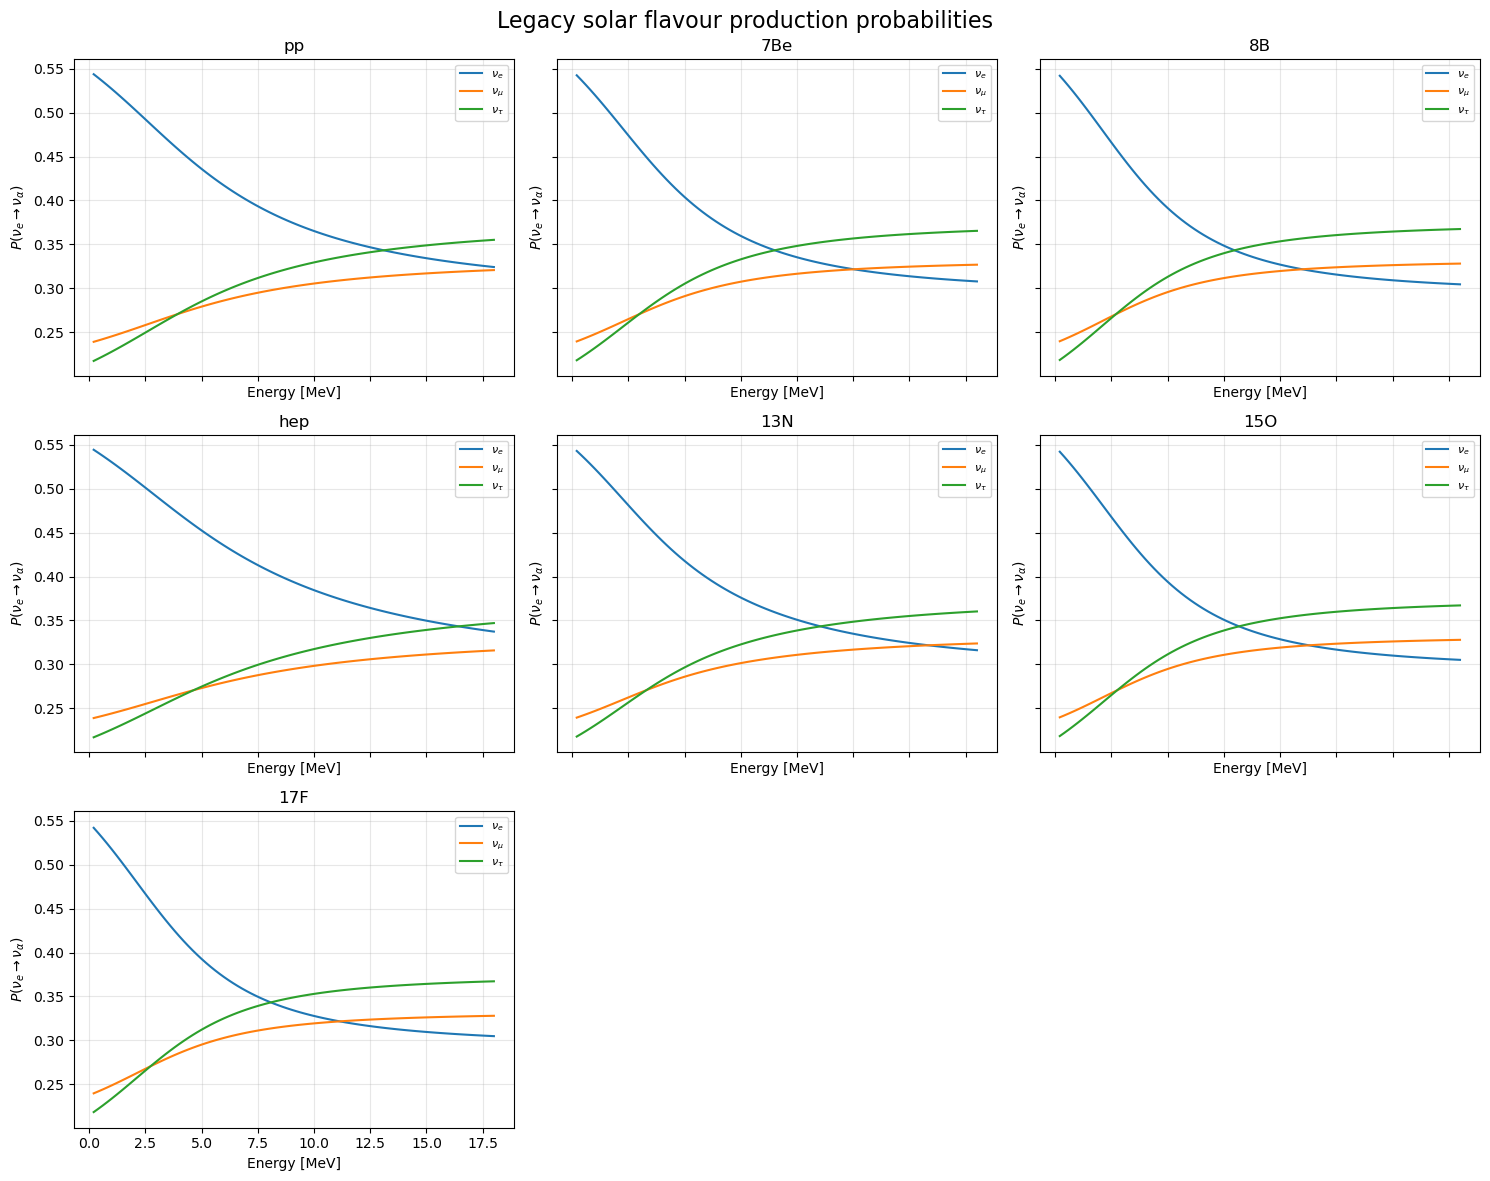

WindowsPath('V:/output/analysis/solar/analysis_solar1_peanuts_legacy/figure_003.png')

In [7]:
ncols = 3
nrows = int(np.ceil(len(available_sources) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows), sharex=True, sharey=True)
axes = np.asarray(axes).reshape(-1)
for ax, source in zip(axes, available_sources):
    probs = np.stack([
        Psolar(legacy_pmns, DM21_EV2, DM3L_EV2, float(E), legacy_solar.radius(), legacy_solar.density(), legacy_solar.fraction(source))
        for E in ENERGY_MEV
    ])
    for i, label in enumerate(FLAVOUR_LABELS):
        ax.plot(ENERGY_MEV, probs[:, i], label=label)
    ax.set_title(source)
    ax.set_xlabel("Energy [MeV]")
    ax.set_ylabel(r"$P(\nu_e\to\nu_\alpha)$")
    ax.legend(fontsize=8)
for ax in axes[len(available_sources):]:
    ax.axis("off")
fig.suptitle("Legacy solar flavour production probabilities", fontsize=16)
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 4. Earth Analytical vs Numerical `Pearth`

This section compares analytical and numerical Earth propagation for a grid of energies and nadir angles. The left panel overlays the electron-flavour component from both methods, while the right panel shows the maximum relative difference across final flavours.


In [12]:
NUMERICAL = False
if NUMERICAL:
    state = np.array([0.0, 1.0, 0.0], dtype=float)
    comparison_etas = np.asarray(NADIR_ANGLES, dtype=float)
    P_an_grid = np.zeros((len(EARTH_METHOD_ENERGY_MEV), len(comparison_etas), 3))
    P_num_grid = np.zeros_like(P_an_grid)
    
    for iE, E_case in enumerate(EARTH_METHOD_ENERGY_MEV):
        for j, eta_case in enumerate(comparison_etas):
            P_an_grid[iE, j] = Pearth(state, legacy_earth, legacy_pmns, DM21_EV2, DM3L_EV2, float(E_case), float(eta_case), EARTH_DEPTH_M, mode="analytical", massbasis=False)
            P_num_grid[iE, j] = Pearth(state, legacy_earth, legacy_pmns, DM21_EV2, DM3L_EV2, float(E_case), float(eta_case), EARTH_DEPTH_M, mode="numerical", massbasis=False)
    
    rel_grid = np.max(np.abs(P_num_grid - P_an_grid) / np.maximum(np.abs(P_an_grid), 1.0e-15), axis=-1)
    for iE, E_case in enumerate(EARTH_METHOD_ENERGY_MEV):
        for j, eta_case in enumerate(comparison_etas):
            print(f"E={E_case:.2f} MeV | eta={eta_case/math.pi:.2f} pi | max relative error={rel_grid[iE, j]:.3e}")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True)
    for j, eta_case in enumerate(comparison_etas):
        axes[0].plot(EARTH_METHOD_ENERGY_MEV, P_an_grid[:, j, 0], "-", label=rf"analytical $P_e$, $\eta={eta_case/math.pi:.2f}\pi$")
        axes[0].plot(EARTH_METHOD_ENERGY_MEV, P_num_grid[:, j, 0], "--", label=rf"numerical $P_e$, $\eta={eta_case/math.pi:.2f}\pi$")
        axes[1].plot(EARTH_METHOD_ENERGY_MEV, rel_grid[:, j], marker="o", label=rf"$\eta={eta_case/math.pi:.2f}\pi$")
    axes[0].set_xlabel("Energy [MeV]")
    axes[0].set_ylabel("Probability")
    axes[0].set_title(r"$\nu_\mu$ initial state: analytical vs numerical")
    axes[1].set_xlabel("Energy [MeV]")
    axes[1].set_ylabel("Max relative difference")
    axes[1].set_yscale("log")
    axes[1].set_title("Relative method difference")
    axes[0].legend(fontsize=7)
    axes[1].legend(fontsize=8)
    fig.tight_layout()
    save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 5. Pure-State Earth Oscillations

This section propagates pure electron, muon, and tau flavour states through Earth for three fixed nadir angles.


In [13]:
if NUMERICAL:
    initial_states = [np.eye(3)[i] for i in range(3)]
    fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharex=False, sharey=True)
    for row, eta in enumerate(NADIR_ANGLES):
        for col, state in enumerate(initial_states):
            sol, x = Pearth(state, legacy_earth, legacy_pmns, DM21_EV2, DM3L_EV2, EARTH_ENERGY_MEV, eta, EARTH_DEPTH_M, mode="numerical", massbasis=False, full_oscillation=True)
            sol = np.asarray(sol)
            for i, label in enumerate(FLAVOUR_LABELS):
                axes[row, col].plot(x, sol[:, i], label=label)
            axes[row, col].set_title(rf"$\eta={eta/math.pi:.2f}\pi$, initial {FLAVOUR_LABELS[col]}")
            axes[row, col].set_xlabel("trajectory coordinate x")
            axes[row, col].set_ylabel("Probability")
            if row == 0 and col == 0:
                axes[row, col].legend(fontsize=8)
    fig.suptitle("Legacy pure-state Earth oscillations", fontsize=16)
    fig.tight_layout()
    save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 6. Solar-to-Detector Probabilities and Fluxes

This section combines solar mass-eigenstate production with Earth propagation to a detector at the configured depth.


In [14]:
def solar_mass_weights_legacy(source: str, energy_mev: float) -> np.ndarray:
    return np.asarray(
        solar_flux_mass(
            legacy_pmns.theta12,
            legacy_pmns.theta13,
            DM21_EV2,
            DM3L_EV2,
            float(energy_mev),
            legacy_solar.radius(),
            legacy_solar.density(),
            legacy_solar.fraction(source),
        ),
        dtype=float,
    )


def earth_detector_probability_legacy(source: str, energy_mev: float, eta: float) -> np.ndarray:
    weights = solar_mass_weights_legacy(source, energy_mev)
    return np.asarray(
        Pearth(weights, legacy_earth, legacy_pmns, DM21_EV2, DM3L_EV2, float(energy_mev), float(eta), EARTH_DEPTH_M, mode="analytical", massbasis=True),
        dtype=float,
    )


def solar_detector_probability_flux_legacy(energy_mev: np.ndarray, eta: float) -> tuple[np.ndarray, np.ndarray]:
    probabilities = np.zeros((len(energy_mev), 3))
    fluxes = np.zeros_like(probabilities)
    total_source_flux = np.zeros(len(energy_mev))
    for source in available_sources:
        source_flux = relative_flux_density(source, energy_mev, legacy_solar.flux(source), spectra_dir=SOLAR_SPECTRA_DIR)
        source_probs = np.stack([earth_detector_probability_legacy(source, E, eta) for E in energy_mev])
        fluxes += source_flux[:, None] * source_probs
        total_source_flux += source_flux
    probabilities = fluxes / np.maximum(total_source_flux[:, None], 1.0e-300)
    return probabilities, fluxes


def solar_detector_probability_flux_eta_legacy(eta_values: np.ndarray, energy_mev: float) -> tuple[np.ndarray, np.ndarray]:
    probabilities = np.zeros((len(eta_values), 3))
    fluxes = np.zeros_like(probabilities)
    total_source_flux = 0.0
    for source in available_sources:
        source_flux = relative_flux_density(source, np.asarray([energy_mev]), legacy_solar.flux(source), spectra_dir=SOLAR_SPECTRA_DIR)[0]
        source_probs = np.stack([earth_detector_probability_legacy(source, energy_mev, eta) for eta in eta_values])
        fluxes += source_flux * source_probs
        total_source_flux += source_flux
    probabilities = fluxes / max(total_source_flux, 1.0e-300)
    return probabilities, fluxes


### 6.1. Energy Dependence

This subsection fixes the nadir angle and shows detector probabilities and detected flavour fluxes as functions of energy.


Saved figure: V:\output\analysis\solar\analysis_solar1_peanuts_legacy\figure_004.png


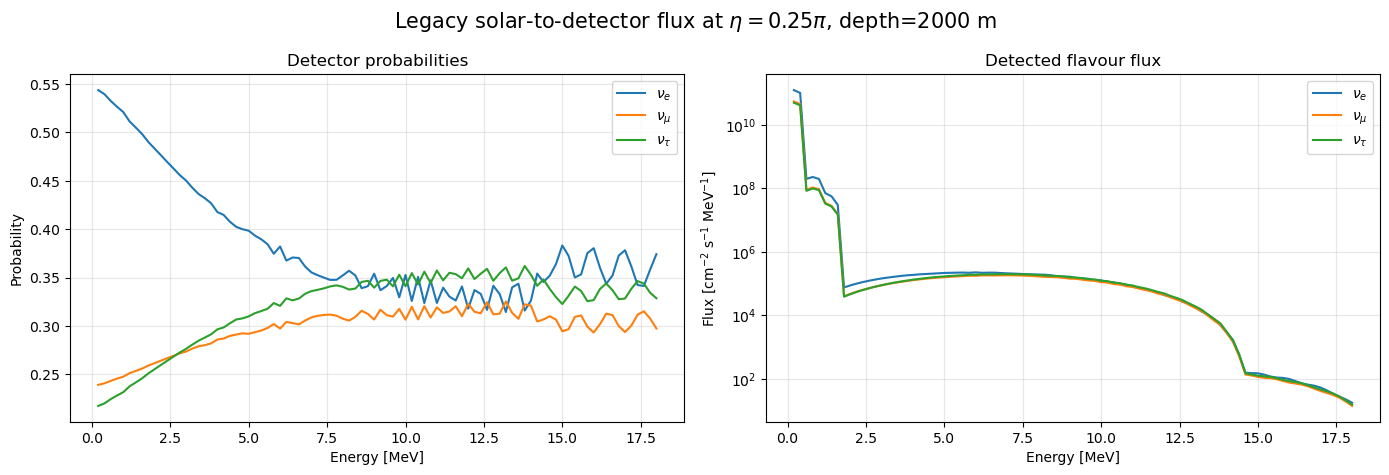

In [15]:
detector_prob_E, detector_flux_E = solar_detector_probability_flux_legacy(ENERGY_MEV, SOLAR_DETECTOR_NADIR)
plot_probability_and_flux(
    ENERGY_MEV,
    detector_prob_E,
    detector_flux_E,
    rf"Legacy solar-to-detector flux at $\eta={SOLAR_DETECTOR_NADIR/math.pi:.2f}\pi$, depth={EARTH_DEPTH_M:.0f} m",
)


### 6.2. Nadir-Angle Dependence

This subsection fixes the neutrino energy and shows detector probabilities and detected flavour fluxes as functions of the nadir angle.


Saved figure: V:\output\analysis\solar\analysis_solar1_peanuts_legacy\figure_005.png


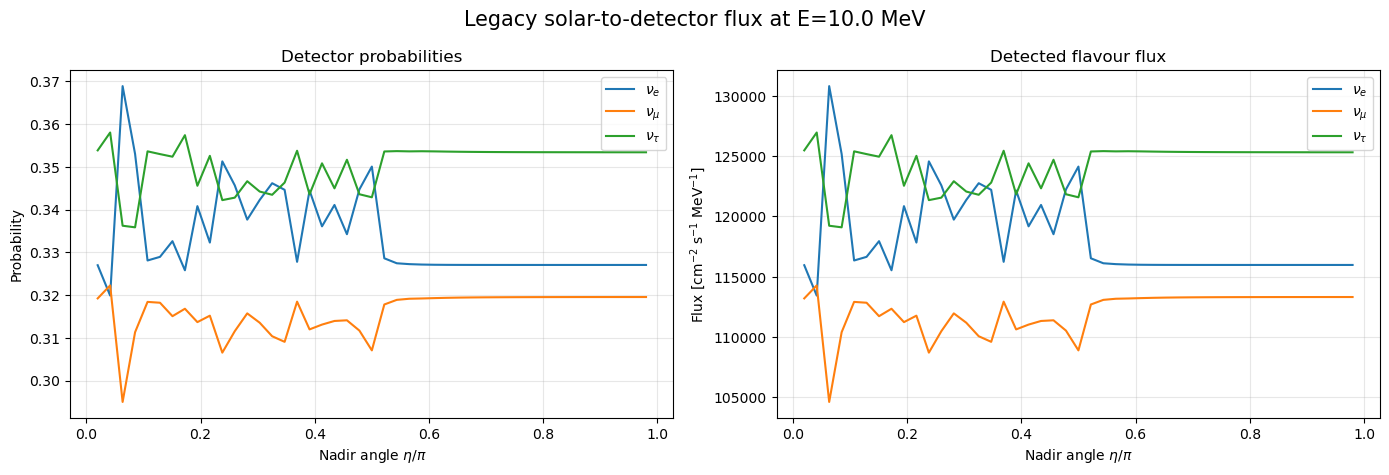

WindowsPath('V:/output/analysis/solar/analysis_solar1_peanuts_legacy/figure_005.png')

In [16]:
eta_grid = np.linspace(0.02 * math.pi, 0.98 * math.pi, 45)
detector_prob_eta, detector_flux_eta = solar_detector_probability_flux_eta_legacy(eta_grid, SOLAR_DETECTOR_ENERGY_MEV)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharex=True)
for i, label in enumerate(FLAVOUR_LABELS):
    axes[0].plot(eta_grid / math.pi, detector_prob_eta[:, i], label=label)
    axes[1].plot(eta_grid / math.pi, detector_flux_eta[:, i], label=label)
axes[0].set_xlabel(r"Nadir angle $\eta/\pi$")
axes[0].set_ylabel("Probability")
axes[0].set_title("Detector probabilities")
axes[1].set_xlabel(r"Nadir angle $\eta/\pi$")
axes[1].set_ylabel(r"Flux [cm$^{-2}$ s$^{-1}$ MeV$^{-1}$]")
axes[1].set_title("Detected flavour flux")
axes[0].legend()
axes[1].legend()
fig.suptitle(rf"Legacy solar-to-detector flux at E={SOLAR_DETECTOR_ENERGY_MEV:.1f} MeV", fontsize=15)
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 7. Annual Solar Neutrino Probabilities

This section integrates the solar-to-detector probabilities over the yearly nadir-angle exposure of the configured detector latitude.


In [17]:
def annual_probability_flux_legacy(energy_mev: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    exposure_table = NadirExposure(lam=DETECTOR_LATITUDE_RAD, d1=0, d2=365, ns=ANNUAL_NADIR_SAMPLES, normalized=True)
    eta_values = exposure_table[:, 0]
    exposure = exposure_table[:, 1]
    probability_eta = []
    flux_eta = []
    for eta in eta_values:
        prob, flux = solar_detector_probability_flux_legacy(energy_mev, float(eta))
        probability_eta.append(prob)
        flux_eta.append(flux)
    probability_eta = np.asarray(probability_eta)
    flux_eta = np.asarray(flux_eta)
    annual_prob = np.trapz(probability_eta * exposure[:, None, None], x=eta_values, axis=0)
    annual_flux = np.trapz(flux_eta * exposure[:, None, None], x=eta_values, axis=0)
    return annual_prob, annual_flux, exposure_table


### 7.1. Probabilities vs Energy

This subsection plots the annual-exposure-averaged detector probabilities as functions of energy.


Saved figure: V:\output\analysis\solar\analysis_solar1_peanuts_legacy\figure_006.png


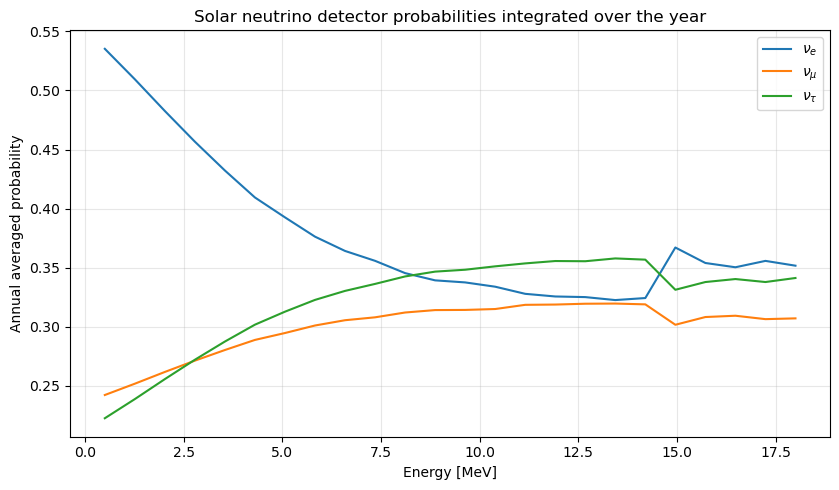

WindowsPath('V:/output/analysis/solar/analysis_solar1_peanuts_legacy/figure_006.png')

In [18]:
annual_prob_E, annual_flux_E, annual_exposure = annual_probability_flux_legacy(ANNUAL_ENERGY_MEV)

fig, ax = plt.subplots(figsize=(8.5, 5.0))
for i, label in enumerate(FLAVOUR_LABELS):
    ax.plot(ANNUAL_ENERGY_MEV, annual_prob_E[:, i], label=label)
ax.set_xlabel("Energy [MeV]")
ax.set_ylabel("Annual averaged probability")
ax.set_title("Solar neutrino detector probabilities integrated over the year")
ax.legend()
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


### 7.2. Fluxes vs Energy

This subsection plots the annual-exposure-averaged detected flavour fluxes as functions of energy.


Saved figure: V:\output\analysis\solar\analysis_solar1_peanuts_legacy\figure_007.png


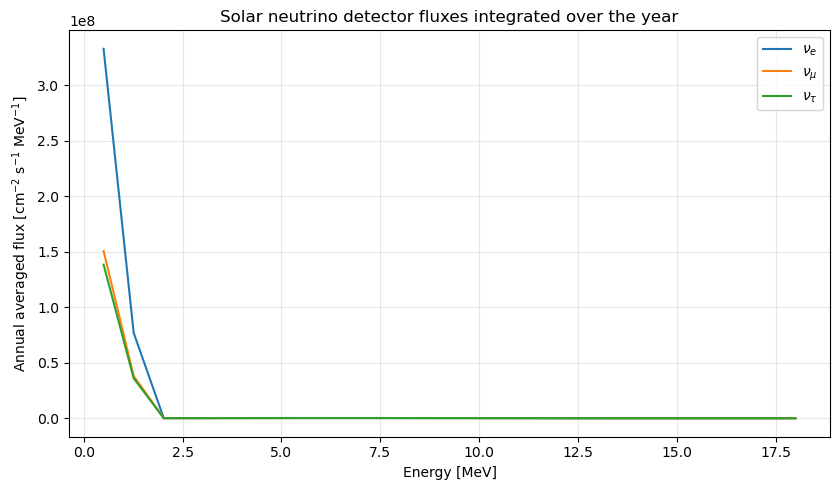

WindowsPath('V:/output/analysis/solar/analysis_solar1_peanuts_legacy/figure_007.png')

In [19]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
for i, label in enumerate(FLAVOUR_LABELS):
    ax.plot(ANNUAL_ENERGY_MEV, annual_flux_E[:, i], label=label)
ax.set_xlabel("Energy [MeV]")
ax.set_ylabel(r"Annual averaged flux [cm$^{-2}$ s$^{-1}$ MeV$^{-1}$]")
ax.set_title("Solar neutrino detector fluxes integrated over the year")
ax.legend()
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 8. Annual Energy-Integrated Detected Neutrinos

This section integrates the annual flux over energy and builds a bar chart with the total number of neutrinos of each flavour crossing the configured detector area per year.


Saved figure: V:\output\analysis\solar\analysis_solar1_peanuts_legacy\figure_008.png


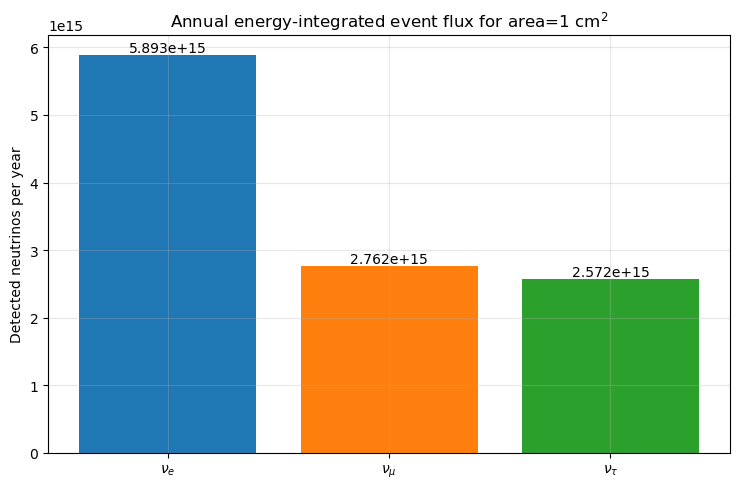

nu_e: 5.892948e+15 neutrinos/year for detector area 1 cm^2
nu_mu: 2.762482e+15 neutrinos/year for detector area 1 cm^2
nu_tau: 2.571763e+15 neutrinos/year for detector area 1 cm^2


In [20]:
detected_per_year = np.trapz(annual_flux_E, x=ANNUAL_ENERGY_MEV, axis=0) * SECONDS_PER_YEAR * DETECTOR_AREA_CM2

fig, ax = plt.subplots(figsize=(7.5, 5.0))
bars = ax.bar([r"$\nu_e$", r"$\nu_\mu$", r"$\nu_\tau$"], detected_per_year, color=["tab:blue", "tab:orange", "tab:green"])
ax.set_ylabel(r"Detected neutrinos per year")
ax.set_title(rf"Annual energy-integrated event flux for area={DETECTOR_AREA_CM2:g} cm$^2$")
ax.bar_label(bars, fmt="%.3e")
fig.tight_layout()
save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

for label, value in zip(["nu_e", "nu_mu", "nu_tau"], detected_per_year):
    print(f"{label}: {value:.6e} neutrinos/year for detector area {DETECTOR_AREA_CM2:g} cm^2")
